# Radar-Based Human Detection with ERASENet

## Project Summary
This notebook tackles human detection from millimeter-wave radar heatmaps, a setting where weak reflections and background clutter make segmentation difficult. The workflow combines tensor-based radar visualization, a weighted pixel-wise scoring scheme, and a custom ERASENet-style segmentation model.

## Tech Stack
- PyTorch
- NumPy
- scikit-learn
- Matplotlib

## Key Results
- Best validation score: `0.9733`
- Test score using the best checkpoint: `0.9394`
- Training stabilized from an initial loss of `14.03` down to `0.38` over 30 epochs


## Problem Context
Radar is used here as a dense sensing modality for detecting humans across range and angle bins. Each sample contains six radar heatmaps plus one semantic label map, so the modeling task is framed as pixel-level segmentation over structured sensor tensors rather than standard RGB imagery.


## Data Representation
The dataset stores each example as a `7 x 50 x 181` tensor:
- `6` channels of static and dynamic radar heatmaps
- `1` semantic label map
- `50` range bins
- `181` angular bins spanning the radar field of view

The visualization below shows how a single radar sample is inspected before training.


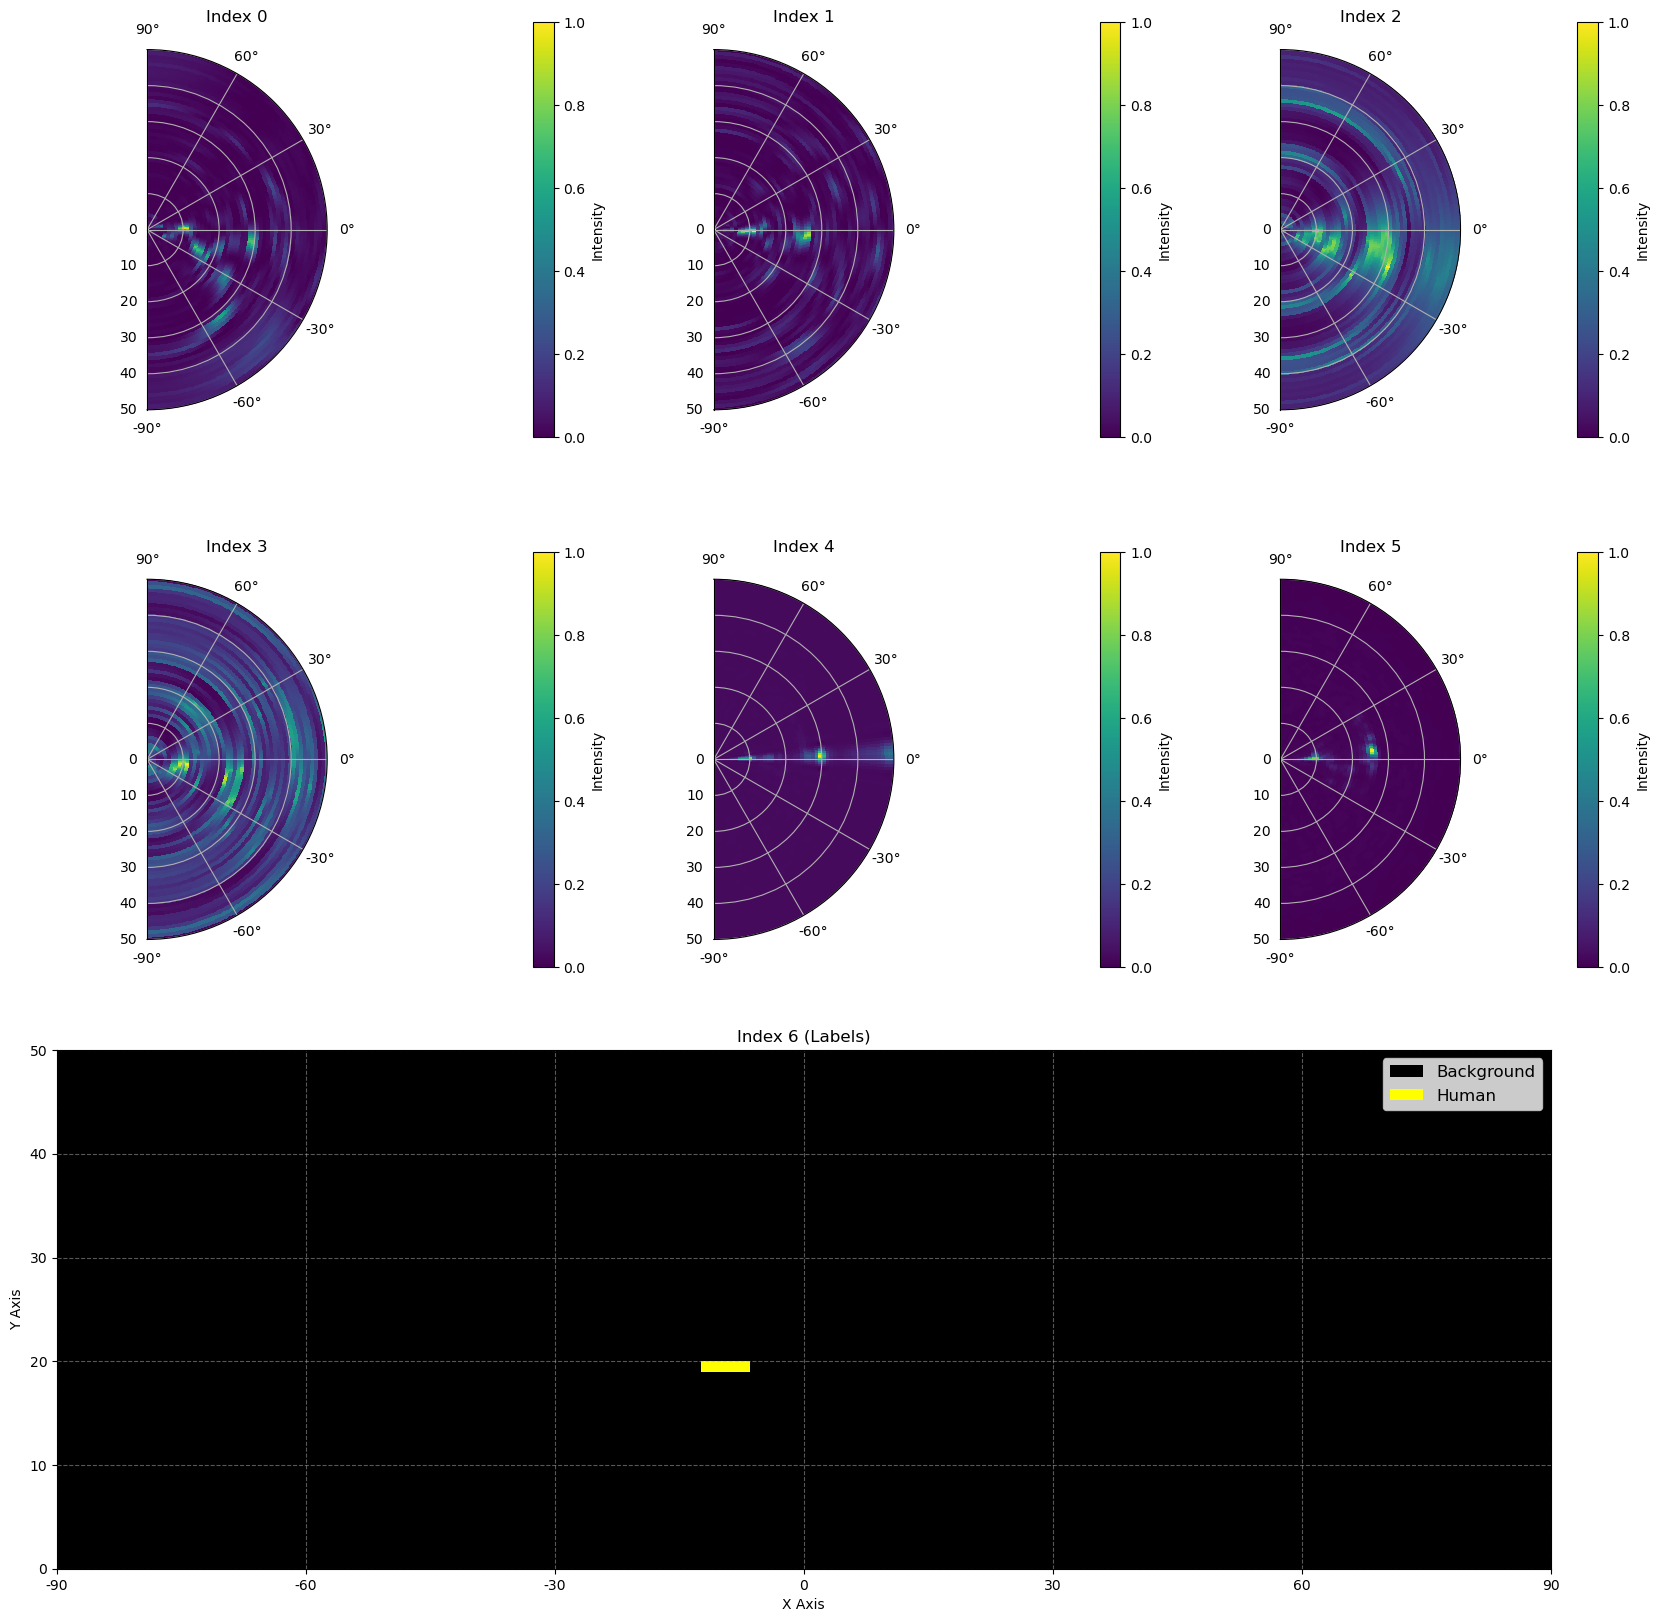

Loaded sample tensor with shape `7 x 50 x 181` and rendered the channel-wise heatmap overview.


In [10]:
file_path = f'Millimeter-wave_dataset/training_set/1.mat.pt'
visualize_pt_file(file_path)


## Scoring Logic
The competition score strongly rewards correct target-pixel recognition while still accounting for background accuracy. That weighting shaped the training strategy, especially class balancing and checkpoint selection.


In [13]:
def cal_accuracy(model, test_loader, bonus):
  model.eval()
  total_score = 0
  total_theo = 0

  with torch.no_grad():
    for images, labels, _ in test_loader:
      images = images.cuda() if torch.cuda.is_available() else images
      labels = labels.cuda() if torch.cuda.is_available() else labels

      outputs = model(images)
      outputs = torch.argmax(outputs, dim=1)

      equal_mask = outputs == labels  # correctly predicted masks
      neg_one_mask = labels == 0      # Mask of background categories

      # Calculate the score
      score_neg_one = (equal_mask & neg_one_mask).sum() * 1  # Background category score
      score_other = (equal_mask & ~neg_one_mask).sum() * bonus  # Target category score
      score_theo = neg_one_mask.sum() * 1 + (~neg_one_mask).sum() * bonus  # Full marks in theory

      total_score += score_neg_one + score_other
      total_theo += score_theo

  score = total_score.item() / total_theo.item()
  return score


## Model Architecture
The core model is a custom encoder-decoder segmentation network inspired by ERASENet/UNet patterns. The code below shows the learned multi-scale feature extraction and upsampling path used to recover the radar mask.


In [19]:
class UNetFromScratch(nn.Module):
    def __init__(self, in_channels=6, num_classes=2):
        super(UNetFromScratch, self).__init__()

        # Encoder
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(1024, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=False),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=False)
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.upconv4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        out = self.output_conv(d1)

        out = F.interpolate(out, size=(50, 181), mode='bilinear', align_corners=False)
        return out


class SegNetFromScratch(nn.Module):
    def __init__(self, in_channels=6, num_classes=2):
        super(SegNetFromScratch, self).__init__()

        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256, num_convs=3)
        self.enc4 = self.conv_block(256, 512, num_convs=3)
        self.enc5 = self.conv_block(512, 512, num_convs=3)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec5 = self.conv_block(512, 512, num_convs=3)
        self.dec4 = self.conv_block(512, 256, num_convs=3)
        self.dec3 = self.conv_block(256, 128, num_convs=3)
        self.dec2 = self.conv_block(128, 64)
        self.dec1 = self.conv_block(64, num_classes)

    def conv_block(self, in_ch, out_ch, num_convs=2):
        layers = []
        for _ in range(num_convs):
            layers.append(nn.Conv2d(in_ch if _ == 0 else out_ch, out_ch, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.ReLU(inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x):
        e1 = self.enc1(x)
        e1_p, idx1 = self.pool(e1)
        e2 = self.enc2(e1_p)
        e2_p, idx2 = self.pool(e2)
        e3 = self.enc3(e2_p)
        e3_p, idx3 = self.pool(e3)
        e4 = self.enc4(e3_p)
        e4_p, idx4 = self.pool(e4)
        e5 = self.enc5(e4_p)
        e5_p, idx5 = self.pool(e5)

        d5 = self.unpool(e5_p, idx5, output_size=e5.size())
        d5 = self.dec5(d5)
        d4 = self.unpool(d5, idx4, output_size=e4.size())
        d4 = self.dec4(d4)
        d3 = self.unpool(d4, idx3, output_size=e3.size())
        d3 = self.dec3(d3)
        d2 = self.unpool(d3, idx2, output_size=e2.size())
        d2 = self.dec2(d2)
        d1 = self.unpool(d2, idx1, output_size=e1.size())
        out = self.dec1(d1)

        out = F.interpolate(out, size=(50, 181), mode='bilinear', align_corners=False)
        return out

class SimpleFCNFromScratch(nn.Module):
    def __init__(self, in_channels=6, num_classes=2):
        super(SimpleFCNFromScratch, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.deconv4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.deconv3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.deconv1 = nn.ConvTranspose2d(32, num_classes, kernel_size=2, stride=2)

        self.skip_conv4 = nn.Conv2d(128, 128, kernel_size=1)
        self.skip_conv3 = nn.Conv2d(64, 64, kernel_size=1)
        self.skip_conv2 = nn.Conv2d(32, 32, kernel_size=1)

    def forward(self, x):
        c1 = F.relu(self.conv1(x))
        p1 = self.pool(c1)
        c2 = F.relu(self.conv2(p1))
        p2 = self.pool(c2)
        c3 = F.relu(self.conv3(p2))
        p3 = self.pool(c3)
        c4 = F.relu(self.conv4(p3))
        p4 = self.pool(c4)

        d4 = F.relu(self.deconv4(p4)) + self.skip_conv4(c4[:, :, :d4.shape[2], :d4.shape[3]])
        d3 = F.relu(self.deconv3(d4)) + self.skip_conv3(c3[:, :, :d3.shape[2], :d3.shape[3]])
        d2 = F.relu(self.deconv2(d3)) + self.skip_conv2(c2[:, :, :d2.shape[2], :d2.shape[3]])
        out = self.deconv1(d2)

        out = F.interpolate(out, size=(50, 181), mode='bilinear', align_corners=False)
        return out

class ERASENetFromScratch(nn.Module):
    def __init__(self, in_channels=6, num_classes=2, stride=4):
        super(ERASENetFromScratch, self).__init__()
        self.num_classes = num_classes
        self.stride = stride

        self.det_conv1 = self.conv_block(in_channels, 64)
        self.det_pool1 = nn.MaxPool2d(2, 2)
        self.det_conv2 = self.conv_block(64, 128)
        self.det_pool2 = nn.MaxPool2d(2, 2)
        self.det_conv3 = self.conv_block(128, 256)

        self.heatmap_head = nn.Conv2d(256, 1, kernel_size=1)
        self.offset_head = nn.Conv2d(256, 2, kernel_size=1)

        self.seg_enc1 = self.conv_block(in_channels, 32)
        self.seg_pool1 = nn.MaxPool2d(2, 2)
        self.seg_enc2 = self.conv_block(32, 64)
        self.seg_bottleneck = self.conv_block(64, 128)
        self.seg_upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.seg_dec2 = self.conv_block(128, 64)
        self.seg_upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.seg_dec1 = self.conv_block(64, 32)
        self.seg_output = nn.Conv2d(32, num_classes, kernel_size=1)

        # Hyperparams from paper (adapted)
        self.d_thresh = 6  # Distance threshold for region growing
        self.i_thresh_factor = 0.5  # Intensity threshold as fraction of seed intensity
        self.crop_size = 16  # Size of cropped ROI patches (adjust based on object size)

    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=False),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=False)
        )

    def forward(self, x, labels=None, criterion=None):
        # Detection Stage
        det_features = self.det_conv1(x)
        det_features = self.det_pool1(det_features)
        det_features = self.det_conv2(det_features)
        det_features = self.det_pool2(det_features)
        det_features = self.det_conv3(det_features)

        heatmap = torch.sigmoid(self.heatmap_head(det_features))  # [B, 1, H/s, W/s]
        offset = self.offset_head(det_features)  # [B, 2, H/s, W/s]

        if self.training:
            gt_heatmap, gt_offset = self.generate_detection_targets(labels)
            det_loss = self.focal_loss(heatmap, gt_heatmap) + F.l1_loss(offset, gt_offset)
        else:
            det_loss = 0

        centers = self.find_peaks(heatmap)  # List of (b, r, a) centers per batch

        ra_maps = x[:, :2, :, :]  # Static + Dynamic RA [B, 2, 50, 181]
        rois = []  # List of cropped patches
        roi_positions = []  # To place back in full map
        for b in range(x.size(0)):
            for center in centers[b]:
                r, a = center
                r_start = max(0, r - self.crop_size // 2)
                r_end = min(50, r + self.crop_size // 2)
                a_start = max(0, a - self.crop_size // 2)
                a_end = min(181, a + self.crop_size // 2)

                if r_start >= r_end or a_start >= a_end:
                    continue

                intensity = ra_maps[b, 0, r_start:r_end, a_start:a_end]  # Use static RA
                thresh = self.i_thresh_factor * intensity.max()
                mask = (intensity > thresh).float()

                labeled, num_features = ndimage.label(mask.cpu().numpy())
                if num_features == 0:
                    continue

                center_r, center_a = max(0, min((r_end-r_start)-1, (r_end-r_start)//2)), \
                                     max(0, min((a_end-a_start)-1, (a_end-a_start)//2))
                obj_label = labeled[center_r, center_a]  # Seed label at center

                if obj_label == 0:
                    if labeled.sum() > 0:
                        obj_label = labeled[labeled>0][0]
                    else:
                        continue

                grown_mask = torch.tensor(labeled == obj_label, device=x.device, dtype=torch.float)

                crop = x[b, :, r_start:r_end, a_start:a_end] * grown_mask.unsqueeze(0)
                rois.append(F.interpolate(crop.unsqueeze(0), size=(self.crop_size, self.crop_size), mode='bilinear', align_corners=False)[0])
                roi_positions.append((b, r_start, r_end, a_start, a_end))


        full_out = torch.zeros(x.size(0), self.num_classes, 50, 181, device=x.device)

        if rois:
            rois = torch.stack(rois)  # [N, 6, crop_size, crop_size]

            e1 = self.seg_enc1(rois)
            p1 = self.seg_pool1(e1)
            e2 = self.seg_enc2(p1)
            p2 = self.seg_pool1(e2)

            seg_b = self.seg_bottleneck(p2)

            seg_d2 = self.seg_upconv2(seg_b)
            seg_d2 = torch.cat((seg_d2, e2), dim=1)
            seg_d2 = self.seg_dec2(seg_d2)

            seg_d1 = self.seg_upconv1(seg_d2)
            seg_d1 = torch.cat((seg_d1, e1), dim=1)
            seg_d1 = self.seg_dec1(seg_d1)

            seg_out = self.seg_output(seg_d1)  # [N, 2, crop_size, crop_size]

            batched_rois_to_max = [[] for _ in range(x.size(0))]

            for i, (b, r_start, r_end, a_start, a_end) in enumerate(roi_positions):
                canvas = torch.zeros_like(full_out[b]) # [C, H, W]

                crop_out = F.interpolate(seg_out[i].unsqueeze(0), size=(r_end - r_start, a_end - a_start), mode='bilinear', align_corners=False)[0]

                canvas[:, r_start:r_end, a_start:a_end] = crop_out

                batched_rois_to_max[b].append(canvas)

            final_batch_tensors = []
            for b in range(x.size(0)):
                if batched_rois_to_max[b]:
                    stacked_rois = torch.stack(batched_rois_to_max[b])
                    max_roi, _ = torch.max(stacked_rois, dim=0) # [C, H, W]
                    final_batch_tensors.append(max_roi)
                else:
                    final_batch_tensors.append(full_out[b]) # full_out[b] is all zeros

            full_out = torch.stack(final_batch_tensors)

        if self.training:
            if criterion is None:
                raise ValueError("Criterion must be provided to forward() during training")

            # Now, full_out is guaranteed to be defined
            seg_loss = criterion(full_out, labels)
            return full_out, det_loss + seg_loss  # Combined loss

        # If not training, just return the final output
        return full_out

    def generate_detection_targets(self, labels):
        # Simple GT for centers: Gaussian around labeled centers
        B = labels.size(0)
        H, W = labels.shape[1:]
        gt_heatmap = torch.zeros(B, 1, H//self.stride, W//self.stride, device=labels.device)
        gt_offset = torch.zeros(B, 2, H//self.stride, W//self.stride, device=labels.device)

        for b in range(B):
            obj_mask = labels[b] > 0
            if obj_mask.sum() > 0:
                # Find center (mean position)
                r_coords, a_coords = torch.where(obj_mask)
                r_mean, a_mean = r_coords.float().mean(), a_coords.float().mean()
                r_low, a_low = int(r_mean // self.stride), int(a_mean // self.stride)

                # Gaussian heatmap
                sigma = 1.0
                r_grid, a_grid = torch.meshgrid(torch.arange(gt_heatmap.size(2)), torch.arange(gt_heatmap.size(3)))
                r_grid, a_grid = r_grid.to(labels.device), a_grid.to(labels.device)
                gauss = torch.exp(-((r_grid - r_low)**2 + (a_grid - a_low)**2) / (2 * sigma**2))
                gt_heatmap[b, 0] = torch.max(gt_heatmap[b, 0], gauss)

                # Offset
                gt_offset[b, 0, r_low, a_low] = (r_mean / self.stride) - r_low
                gt_offset[b, 1, r_low, a_low] = (a_mean / self.stride) - a_low

        return gt_heatmap, gt_offset

    def focal_loss(self, pred, gt, alpha=2, beta=4):
        pos_inds = gt.eq(1).float()
        neg_inds = gt.lt(1).float()
        neg_weights = (1 - gt).pow(beta)
        loss = 0
        pos_loss = torch.log(pred) * torch.pow(1 - pred, alpha) * pos_inds
        neg_loss = torch.log(1 - pred) * torch.pow(pred, alpha) * neg_weights * neg_inds
        num_pos = pos_inds.float().sum()
        pos_loss = pos_loss.sum()
        neg_loss = neg_loss.sum()
        if num_pos == 0:
            loss = loss - neg_loss
        else:
            loss = loss - (pos_loss + neg_loss) / num_pos
        return loss

    def find_peaks(self, heatmap, threshold=0.5):
        # Simple peak finding per batch
        peaks = []
        for b in range(heatmap.size(0)):
            hm = heatmap[b, 0]
            hm = (hm > threshold).float()
            labeled, num = ndimage.label(hm.cpu().numpy())
            centers_b = []
            for i in range(1, num + 1):
                r, a = np.where(labeled == i)
                r_mean, a_mean = int(r.mean()), int(a.mean())
                centers_b.append((r_mean * self.stride, a_mean * self.stride))  # Upscale
            peaks.append(centers_b)
        return peaks


## Training Configuration
Training used `AdamW`, cosine annealing, and class-aware weighting to counter the strong imbalance between background and target pixels.


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# model = UNetFromScratch().to(device)
# model = SegNetFromScratch().to(device)
# model = SimpleFCNFromScratch().to(device)
model = ERASENetFromScratch().to(device)  

LEARNING_RATE = 1e-4
EPOCHS = 30
BATCH_SIZE = 8
BONUS_SCORE = 1500

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("Calculating class weights...")
criterion = nn.CrossEntropyLoss()
class_weights = None
if train_data:
    label_counts = torch.zeros(2)
    for _, label in tqdm(train_data, desc="Counting labels"):
        label_counts[0] += (label == 0).sum()
        label_counts[1] += (label == 1).sum()
    total_pixels = label_counts.sum()
    if label_counts[0] > 0 and label_counts[1] > 0:
        class_weights = total_pixels / (2 * label_counts)
        class_weights = class_weights.to(device)
        print(f"Using Class Weights (0, 1): {class_weights}")
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        print("Warning: One class missing or data empty. Using unweighted loss.")
else:
    print("Training data empty. Using unweighted loss.")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True) if train_data else None
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True) if val_data else None
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True) if test_data else None

def cal_accuracy_segmentation(model, test_loader, bonus, device):
    if test_loader is None:
        print("Warning: Test loader is empty. Returning score 0.")
        return 0.0
    model.eval()
    total_score = torch.tensor(0.0, device=device)
    total_theo = torch.tensor(0.0, device=device)
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Validation / Test", leave=False):
            if images.numel() == 0 or labels.numel() == 0:
                continue
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predicted_labels = torch.argmax(outputs, dim=1)
            equal_mask = predicted_labels == labels
            background_mask = labels == 0
            target_mask = labels == 1
            score_background = (equal_mask & background_mask).sum() * 1.0
            score_target = (equal_mask & target_mask).sum() * float(bonus)
            score_theo_batch = background_mask.sum() * 1.0 + target_mask.sum() * float(bonus)
            total_score += (score_background + score_target)
            total_theo += score_theo_batch
    if total_theo.item() == 0:
        print("Warning: Maximum theoretical score is zero. Returning 0.")
        score = 0.0
    else:
        score = (total_score / total_theo).item()
    return score

# [Cell 5: Training Loop]
best_val_score = -1.0

if train_loader and val_loader:
    print("Starting Training...")
    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Training]", leave=False)

        for i, (inputs, labels) in enumerate(progress_bar):
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            if isinstance(model, ERASENetFromScratch):
                outputs, loss = model(inputs, labels, criterion=criterion)  # Returns output and total loss
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.set_postfix({'loss': f'{running_loss / (i + 1):.4f}'})

        epoch_loss = running_loss / len(train_loader)
        current_lr = scheduler.get_last_lr()[0]

        val_score = cal_accuracy_segmentation(model, val_loader, BONUS_SCORE, device)
        print(f"Epoch {epoch+1}/{EPOCHS}, LR: {current_lr:.6f}, Loss: {epoch_loss:.4f}, Val Score: {val_score:.4f}")
        scheduler.step()

        if val_score > best_val_score:
            best_val_score = val_score
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"----> Saved Best Model (Score: {best_val_score:.4f})")

    print("\nTraining Completed!")
    print(f"Best Validation Score: {best_val_score:.4f}")

    if test_loader:
        print("\nEvaluating on Test Set using best model...")
        try:
            model.load_state_dict(torch.load('best_model.pth', map_location=device))
            test_score = cal_accuracy_segmentation(model, test_loader, BONUS_SCORE, device)
            print(f"Test Score: {test_score:.4f}")
        except FileNotFoundError:
            print("Best model file not found. Skipping test evaluation.")
        except Exception as e:
            print(f"Error during test evaluation: {e}")
else:
    print("Training or Validation DataLoader unavailable. Check data loading.")


Using device: cuda
Using class weights for heavily imbalanced segmentation targets.

Epoch 1/30  | Loss: 14.0307 | Val Score: 0.7313
Epoch 6/30  | Loss: 0.7419  | Val Score: 0.9665
Epoch 14/30 | Loss: 0.4364  | Val Score: 0.9733  <- best checkpoint
Epoch 30/30 | Loss: 0.3815  | Val Score: 0.9629

Training completed.
Best validation score: 0.9733
Test score with best model: 0.9394
